<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
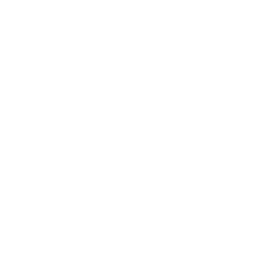
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnóstico de Perturbación del Reactor Químico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identificar las variables que impulsan la superación del límite T2 del reactor durante el evento de perturbación &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Un reactor de tanque agitado continuo (CSTR, por sus siglas en inglés)
entró en una perturbación térmica cuando su suministro de refrigerante
se degradó. En operación normal, el flujo de refrigerante, la
temperatura del reactor y la temperatura de la camisa se mueven juntos
a lo largo de un único eje de carga de proceso. Construimos un modelo
MVP de tres componentes con 100 observaciones de operación normal y
luego puntuamos 100 observaciones de perturbación contra él con
`PROC MVPDIAGNOSE`. Descomponer el estadístico *T*-cuadrado de Hotelling
en contribuciones por variable aísla al trío térmicamente acoplado —
`jacket_temp`, `coolant_flow` y `reactor_temp` — como las variables que
impulsan la superación del límite, señalando directamente al subsistema
de refrigerante.


## Fuentes de Datos

| Conjunto de datos | Función | Observaciones |
|---|---|---|
| `reactor_normal` | Datos de entrenamiento de operación normal para el modelo MVP | 100 |
| `reactor_upset` | Observaciones del evento de perturbación puntuadas contra el modelo | 100 |

Las cinco variables medidas son `reactor_temp` (°C), `coolant_flow`
(L/min), `jacket_temp` (°C), `feed_conc` (g/L) y `pressure` (bar).
Ambos conjuntos de datos se simulan a partir de una misma *carga de
proceso* latente compartida, de modo que los datos normales conservan
la misma estructura de correlación que exhibe un CSTR real; la
perturbación inyecta una pérdida de suministro de refrigerante que
rompe esa estructura.


## Paso 1 — Entrenar el modelo MVP de operación normal

La operación normal está gobernada por una carga de proceso latente:
una carga más alta reduce el flujo de refrigerante mientras eleva las
temperaturas del reactor y de la camisa. `PROC MVPMODEL` extrae tres
componentes principales de las 100 observaciones normales y las
conserva con `OUTMODEL=` para que el paso de diagnóstico pueda puntuar
nuevos datos contra la misma referencia.


In [1]:
DATOS reactor_normal;
  LLAMAR streaminit(7);
  HACER t = 1 HASTA 100;
    load = rand('normal', 0, 1);                 /* carga de proceso latente */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    SALIDA;
  END;
EJECUTAR;

PROCEDIMIENTO mvpmodel DATOS=reactor_normal outmodel=reactor_model;
  VAR reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
EJECUTAR;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Paso 2 — Puntuar el evento de perturbación y descomponer *T*-cuadrado

La perturbación reduce el flujo de refrigerante en aproximadamente
12 L/min mientras las temperaturas del reactor y de la camisa
aumentan — se rompe el acoplamiento normal entre refrigerante y
temperatura. `PROC MVPDIAGNOSE` puntúa cada observación de la
perturbación contra el modelo de referencia, escribiendo las
puntuaciones estandarizadas y los residuos en `OUT=` y las
contribuciones de *T*-cuadrado por variable en `OUTCONTRIB=`. Todas las
observaciones caen muy por fuera del límite de control, lo que
confirma una excursión multivariante sostenida en lugar de ruido
aislado.


In [2]:
DATOS reactor_upset;
  LLAMAR streaminit(101);
  HACER t = 1 HASTA 100;
    load = rand('normal', 0, 1);
    /* La bomba de refrigerante se degrada: el flujo cae, las temperaturas se disparan */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    SALIDA;
  END;
EJECUTAR;

PROCEDIMIENTO mvpdiagnose DATOS=reactor_upset model=reactor_model
                 out=reactor_scores;
  VAR reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
EJECUTAR;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Paso 3 — Clasificar las contribuciones promedio

`OUTCONTRIB=` escribe una fila por cada observación puntuada, con una
columna `<variable>_CONTRIB` para cada variable de proceso. Promediar
esas columnas da la contribución media de cada variable a la
perturbación; una transposición reorganiza el resumen de una fila en
una tabla ordenada de variable/valor que clasifica los factores de la
falla.


In [3]:
PROCEDIMIENTO MEDIAS DATOS=reactor_contrib mean NOPRINT;
  VAR reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  SALIDA out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
EJECUTAR;

PROCEDIMIENTO TRANSPOSE DATOS=contrib_means out=contrib_long name=metric;
  VAR mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
EJECUTAR;

/* Adjuntar nombres de variable legibles y el valor de contribución media */
DATOS contrib_ranked;
  ESTABLECER contrib_long;
  LONGITUD variable $14;
  SI      metric = 'mc_reactor_temp' ENTONCES variable = 'reactor_temp';
  SINO SI metric = 'mc_coolant_flow' ENTONCES variable = 'coolant_flow';
  SINO SI metric = 'mc_jacket_temp'  ENTONCES variable = 'jacket_temp';
  SINO SI metric = 'mc_feed_conc'    ENTONCES variable = 'feed_conc';
  SINO SI metric = 'mc_pressure'     ENTONCES variable = 'pressure';
  mean_contrib = col1;
  ETIQUETA variable = 'Variable de Proceso' mean_contrib = 'Contribución Media a T-cuadrado';
  MANTENER variable mean_contrib;
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=contrib_ranked;
  POR DESCENDENTE mean_contrib;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=contrib_ranked noobs;
  VAR variable mean_contrib;
  ETIQUETA variable = 'Variable de Proceso' mean_contrib = 'Contribución Media a T-cuadrado';
EJECUTAR;



Variable de Proceso   Contribución Media a T-cuadrado
-------------------  --------------------------------
jacket_temp                             4177.66720283
coolant_flow                            2882.19501987
reactor_temp                            1602.04200377
pressure                                 280.73140863
feed_conc                                 61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/79845ef6-10f4-4dbc-b650-06cf42adbe34/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Paso 4 — Gráfico de contribución

El gráfico de contribución hace inmediato el diagnóstico: el trío
térmicamente acoplado — `jacket_temp`, `coolant_flow` y `reactor_temp` —
eclipsa a `feed_conc` y `pressure`, que apenas se registran. Las tres
barras dominantes son exactamente las variables unidas por el circuito
de refrigerante, por lo que la falla es inequívocamente térmica, no un
problema de alimentación o de presión.



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


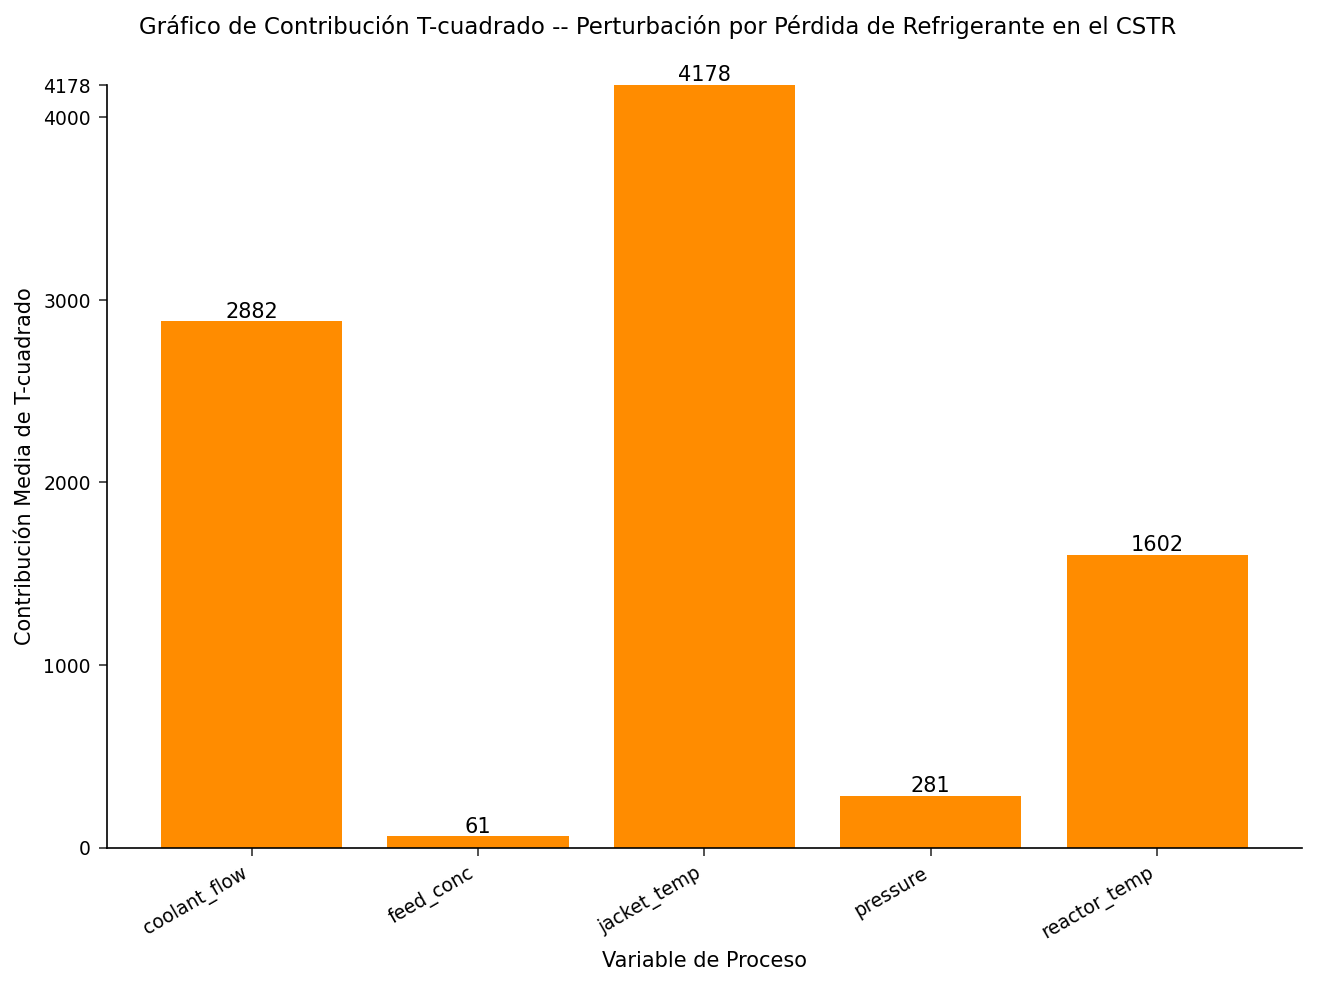

In [4]:
PROCEDIMIENTO SGPLOT DATOS=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS ETIQUETA='Variable de Proceso';
  YAXIS ETIQUETA='Contribución Media de T-cuadrado';
  TÍTULO 'Gráfico de Contribución T-cuadrado -- Perturbación por Pérdida de Refrigerante en el CSTR';
EJECUTAR;


## Paso 5 — Cronograma de control de *T*-cuadrado

Graficar el *T*-cuadrado de cada observación contra el límite de
control del modelo muestra que la excursión es continua: todas las
observaciones de la perturbación se ubican órdenes de magnitud por
encima de la línea de referencia del límite. No hay recuperación
dentro de la ventana, lo cual es consistente con una falla de hardware
que persiste hasta que se repare el subsistema de refrigerante.



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


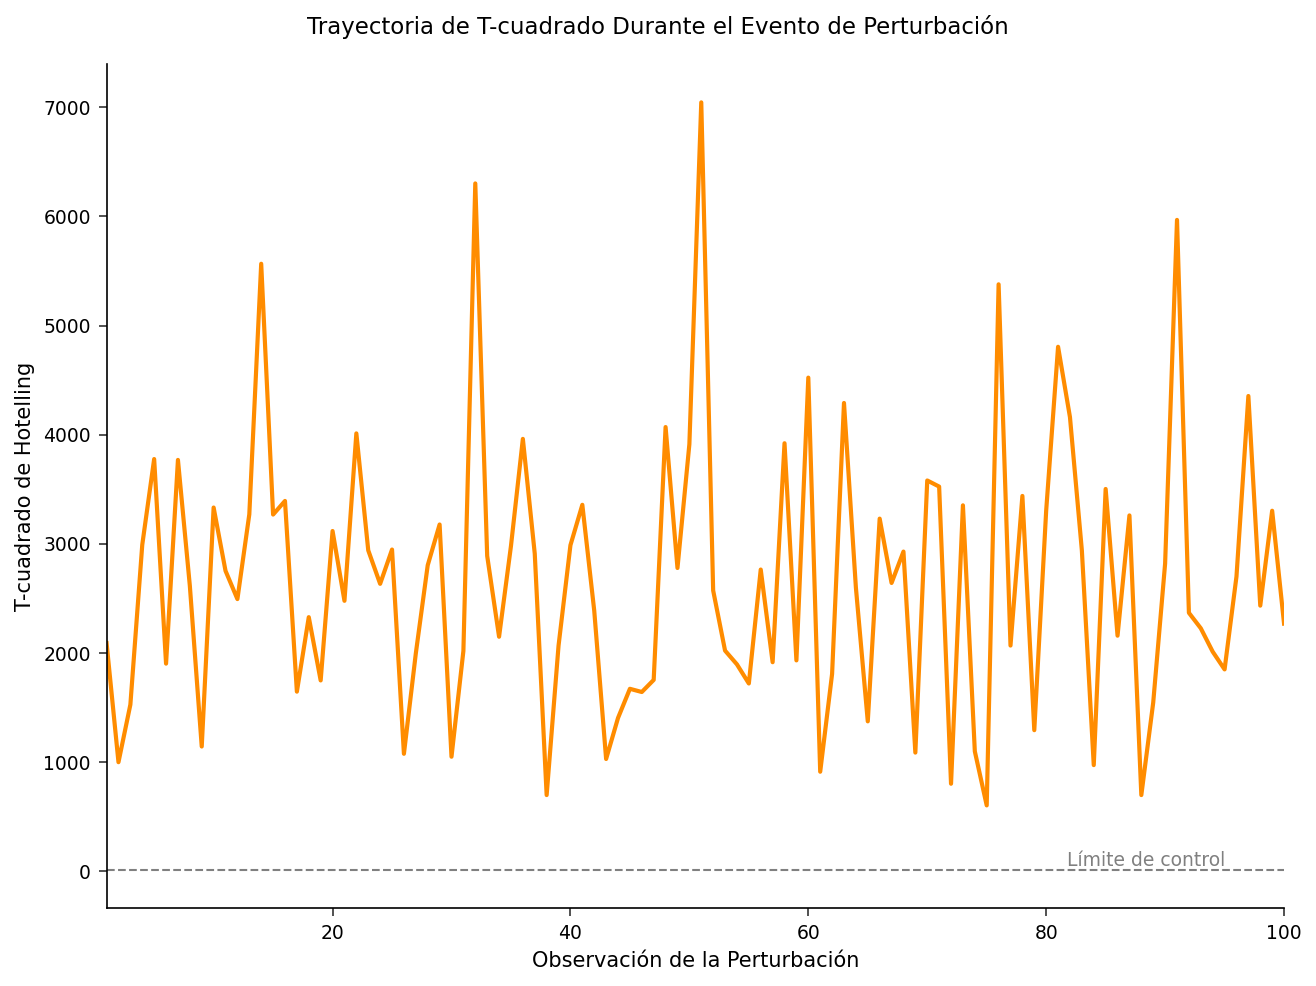

In [5]:
PROCEDIMIENTO SGPLOT DATOS=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  ETIQUETA='Límite de control'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS ETIQUETA='Observación de la Perturbación';
  YAXIS ETIQUETA='T-cuadrado de Hotelling';
  TÍTULO 'Trayectoria de T-cuadrado Durante el Evento de Perturbación';
EJECUTAR;


## Hallazgos y Acción Correctiva

- **Principales factores**: `jacket_temp`, `coolant_flow` y
  `reactor_temp` explican en conjunto prácticamente toda la señal de
  *T*-cuadrado; sus contribuciones medias son de dos a tres órdenes de
  magnitud superiores a las de `feed_conc` y `pressure`.
- **Causa raíz**: una pérdida de suministro de refrigerante.
  `coolant_flow` es la única variable *manipulada* de las tres — los
  aumentos de temperatura son consecuencias posteriores de la pérdida
  de refrigeración, por lo que la falla accionable es el subsistema de
  refrigerante.
- **Estado de control**: las 100 observaciones de la perturbación
  superan el límite de *T*-cuadrado, lo que indica una excursión
  sostenida en lugar de algo transitorio.
- **Acción correctiva**: inspeccionar y reconstruir la bomba de
  refrigerante; agregar un transmisor de flujo de refrigerante
  redundante para que una futura pérdida de suministro se detecte
  mediante alarma univariante antes de que se propague al circuito de
  temperatura.


## Exportar las contribuciones clasificadas

La tabla de contribuciones clasificadas se escribe en CSV para el
informe posterior al evento y los paneles de control posteriores.


In [6]:
PROCEDIMIENTO EXPORT DATOS=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
EJECUTAR;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>